# Step 12 — Does causal ordering mean anything, or is it an arbitrary bottleneck?

The README's own open thread: "causal attention has never clearly beaten mean-pooling
head-to-head at matched size." A concrete hypothesis for why: `weak_learners.py`'s K experts
are trained JOINTLY (one shared loss, one optimizer step), not sequentially on frozen
residuals like real boosting -- so the order they happen to sit in (token 0..K-1, fixed by
`WeakLearnerEnsemble`'s construction, unrelated to anything about the data) is arbitrary.
Causal masking then imposes a directional "expert i sees only 0..i-1" structure on top of
that arbitrary order, plus a LEARNED per-slot position embedding
(`AttentionConfig.use_step_embedding=True` by default) -- two separate sources of
order-dependence, neither justified by anything in how the experts were actually trained.

### The test

Train `meanpool` / `bidirectional` / `causal` once each (multiple seeds), each with the SAME
frozen expert order they were trained with. Then evaluate each trained model TWICE more per
seed: once at the normal (trained) token order, and once with the K tokens randomly
SHUFFLED before entering the attention stage -- no retraining, same weights, only the order
the tokens are presented in at eval time changes.

**What each outcome would mean:**
- If shuffling barely moves the causal/bidirectional arms' accuracy: the trained attention
  weights are (surprisingly) robust to WHICH learner sits in which slot -- order isn't doing
  much, consistent with mean-pool matching it at a fraction of the complexity.
- If shuffling causes a sharp, consistent drop: the model learned something genuinely
  slot-specific (whether via the causal mask, the step embedding, or both) -- but that
  slot-specific structure was fit to an ARBITRARY assignment of learners to slots, which is
  itself evidence the "boosting-like ordering" framing isn't earning its complexity.
- Comparing `causal` (mask + step embedding) against `bidirectional` (step embedding only,
  no mask) isolates how much of any order-sensitivity comes from the causal mask
  specifically vs. the learned positional bias alone.

Runs entirely on CPU (California Housing, small) -- no GPU cluster needed.

## 0. Setup

In [1]:
import os, sys, time, warnings
warnings.filterwarnings("ignore")
PROJECT_DIR = os.getcwd(); sys.path.insert(0, PROJECT_DIR)
os.environ["PYTHONPATH"] = PROJECT_DIR + os.pathsep + os.environ.get("PYTHONPATH", "")

import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt, seaborn as sns

from benchmarks_rtdl import BENCHMARKS, load_benchmark
from training import get_device, to_tensors, train_model, evaluate
from weak_learners import WeakLearnerConfig
from attention import AttentionConfig
from embeddings import EmbeddingConfig
from model import make_arm

DEVICE = get_device()

# Knobs, overridable from the shell so a headless run needs no edits:
#   SRP_SUBSAMPLE=1500 SRP_SEEDS=1 SRP_EPOCHS=3 SRP_PATIENCE=2 SRP_PERMS=2 jupyter nbconvert ...
KEY       = os.environ.get("SRP_KEY", "CA")                 # CA = California Housing
ARMS      = os.environ.get("SRP_ARMS", "meanpool,bidirectional,causal").split(",")
SEEDS     = tuple(range(int(os.environ.get("SRP_SEEDS", "3"))))
N_PERMS   = int(os.environ.get("SRP_PERMS", "10"))            # random shuffles per (arm, seed)
EPOCHS    = int(os.environ.get("SRP_EPOCHS", "60"))            # matches notebook 08's budget
PATIENCE  = int(os.environ.get("SRP_PATIENCE", "8"))
SUBSAMPLE = int(os.environ.get("SRP_SUBSAMPLE", "0")) or None

RUN_DIR = os.path.join(PROJECT_DIR, "runs"); os.makedirs(RUN_DIR, exist_ok=True)
STAMP = time.strftime("%Y%m%d_%H%M%S")
LOG_PATH = os.path.join(RUN_DIR, f"14_progress_{STAMP}.log")
_latest = os.path.join(RUN_DIR, "14_progress.log")
if os.path.islink(_latest) or os.path.exists(_latest):
    os.remove(_latest)
os.symlink(os.path.basename(LOG_PATH), _latest)
def log(msg):
    print(msg, flush=True)
    with open(LOG_PATH, "a") as f: f.write(time.strftime("%H:%M:%S ") + msg + "\n")
def show(df, fmt=None, style=None):
    try:
        s = df.style.format(fmt or {}, na_rep="—"); display(style(s) if style else s)
    except (AttributeError, ImportError):
        display(df.round(4))

sns.set_theme(style="whitegrid", context="notebook")
log(f"device: {DEVICE} | arms={ARMS} | seeds={len(SEEDS)} | permutations/model={N_PERMS} | epochs={EPOCHS}")

device: cpu | arms=['meanpool', 'bidirectional', 'causal'] | seeds=3 | permutations/model=10 | epochs=60


## 1. Data and the fixed config (copied from notebook 08, incl. PLR)

In [2]:
data = load_benchmark(KEY)
arrays = data.arrays()
if SUBSAMPLE:
    n = SUBSAMPLE
    arrays = {"Xtr": arrays["Xtr"][:n], "ytr": arrays["ytr"][:n],
             "Xva": arrays["Xva"][:n // 2], "yva": arrays["yva"][:n // 2],
             "Xte": arrays["Xte"][:n], "yte": arrays["yte"][:n]}
    print(f"SMOKE TEST on {SUBSAMPLE} rows -- numbers below are not comparable to a real run.")
log(data.summary())

# Small head (matches notebook 08's plain arms, not meanpool_wide -- capacity doesn't matter
# for THIS question, only that all 3 arms share the same expert weights per seed, which
# make_arm() already guarantees for a fixed torch seed).
ENS_KW = dict(num_learners=16, hidden_dim=16, embed_dim=32, depth=1, dropout=0.1, feature_frac=0.7)
ATT_KW = dict(embed_dim=32, num_heads=4, attn_depth=2, dropout=0.1, need_weights=False)
EMB_KW = dict(mode="periodic", d_embedding=8, n_frequencies=16, sigma=0.1)
LR, WEIGHT_DECAY = 1e-3, 1e-4
print("fixed config (identical across every arm and seed):")
for name, kw in [("ENS_KW", ENS_KW), ("ATT_KW", ATT_KW), ("EMB_KW", EMB_KW)]:
    print(f"  {name}: {kw}")
print(f"  lr={LR}, weight_decay={WEIGHT_DECAY}")

rng = np.random.RandomState(0)
K = ENS_KW["num_learners"]
PERMS = [rng.permutation(K) for _ in range(N_PERMS)]
print(f"\n{N_PERMS} fixed random permutations of the {K} token slots, shared across every "
      f"arm/seed below so comparisons are apples-to-apples.")

CA California Housing regression features=  8 train=13,209 val=3,303 test=4,128


fixed config (identical across every arm and seed):
  ENS_KW: {'num_learners': 16, 'hidden_dim': 16, 'embed_dim': 32, 'depth': 1, 'dropout': 0.1, 'feature_frac': 0.7}
  ATT_KW: {'embed_dim': 32, 'num_heads': 4, 'attn_depth': 2, 'dropout': 0.1, 'need_weights': False}
  EMB_KW: {'mode': 'periodic', 'd_embedding': 8, 'n_frequencies': 16, 'sigma': 0.1}
  lr=0.001, weight_decay=0.0001

10 fixed random permutations of the 16 token slots, shared across every arm/seed below so comparisons are apples-to-apples.


## 2. Train once per (arm, seed); evaluate at normal order + every permutation

In [3]:
def predict_permuted(model, X, perm=None):
    '''Reproduces SRPModel.forward()'s readout="last" path exactly, with an optional
    token-order permutation inserted right before the aggregator -- no retraining, same
    weights, only which slot each learner's embedding lands in changes.'''
    model.eval()
    with torch.no_grad():
        tokens = model.ensemble(model.embedding(X), x_raw=X)
        if perm is not None:
            tokens = tokens[:, perm, :]
        if model.stage is None:
            z = tokens.mean(dim=1)
        else:
            ctx, _ = model.stage(tokens, need_weights=False)
            z = ctx[:, -1]
        pred = model.head(z)
        return (pred.squeeze(-1) if model.config.output_dim == 1 else pred).cpu().numpy()

t0 = time.time()
tdata = to_tensors(arrays, str(DEVICE))
ROWS = []
for arm in ARMS:
    for seed in SEEDS:
        torch.manual_seed(seed)
        model = make_arm(arm, tdata["Xtr"].shape[1], WeakLearnerConfig(**ENS_KW, seed=seed, batched=True),
                         AttentionConfig(**ATT_KW), task=data.task, output_dim=data.output_dim,
                         embedding=EmbeddingConfig(**EMB_KW))
        model, hist = train_model(model, tdata, seed=seed, epochs=EPOCHS, patience=PATIENCE,
                                  lr=LR, weight_decay=WEIGHT_DECAY)
        from training import regression_metrics, classification_metrics
        def _score(y_pred):
            m = (regression_metrics(arrays["yte"], y_pred) if data.task == "regression"
                 else classification_metrics(arrays["yte"], y_pred, data.task))
            return m["rmse"] if data.task == "regression" else m["acc"]

        base_pred = predict_permuted(model, tdata["Xte"], perm=None)
        base_score = _score(base_pred)
        ROWS.append({"arm": arm, "seed": seed, "perm": "none", "score": base_score})
        for pi, perm in enumerate(PERMS):
            perm_pred = predict_permuted(model, tdata["Xte"], perm=perm)
            ROWS.append({"arm": arm, "seed": seed, "perm": pi, "score": _score(perm_pred)})
        log(f"  arm={arm:14s} seed={seed}  baseline={base_score:.4f}  "
            f"epochs={hist['best_epoch']+1}  elapsed {(time.time()-t0)/60:.1f} min")
RESULTS = pd.DataFrame(ROWS)
log(f"all training + permutation evals done in {(time.time()-t0)/60:.1f} min")

  arm=meanpool       seed=0  baseline=0.4171  epochs=58  elapsed 0.5 min


  arm=meanpool       seed=1  baseline=0.4270  epochs=57  elapsed 0.9 min


  arm=meanpool       seed=2  baseline=0.4195  epochs=58  elapsed 1.3 min


  arm=bidirectional  seed=0  baseline=0.4119  epochs=39  elapsed 3.3 min


  arm=bidirectional  seed=1  baseline=0.4261  epochs=44  elapsed 5.5 min


  arm=bidirectional  seed=2  baseline=0.4054  epochs=50  elapsed 8.0 min


  arm=causal         seed=0  baseline=0.4158  epochs=39  elapsed 10.0 min


  arm=causal         seed=1  baseline=0.4185  epochs=47  elapsed 12.4 min


  arm=causal         seed=2  baseline=0.4326  epochs=41  elapsed 14.5 min


all training + permutation evals done in 14.5 min


## 3. How much does shuffling the token order move each arm's accuracy?

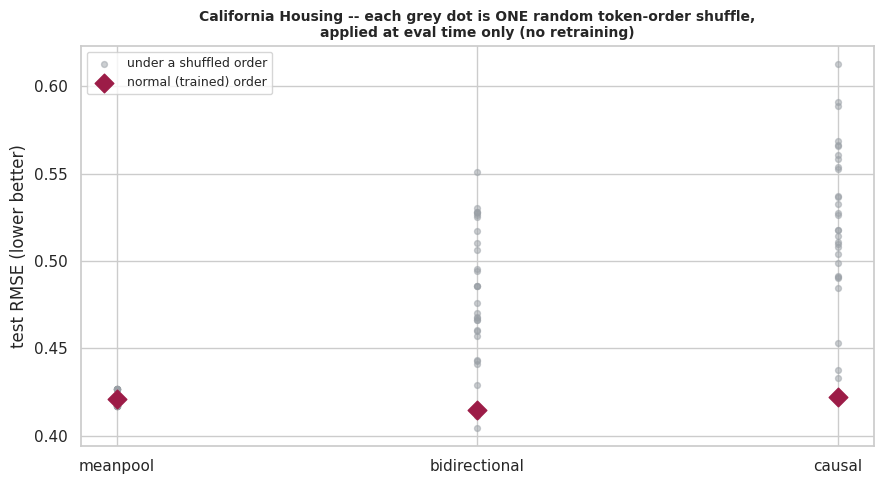

,baseline,shuffled_mean,shuffled_sd,shuffled_min,shuffled_max
arm,,,,,
bidirectional,0.4145,0.4820,0.0378,0.4047,0.5511
causal,0.4223,0.5246,0.0432,0.4328,0.6128
meanpool,0.4212,0.4212,0.0043,0.4171,0.4270


In [4]:
hib = data.task != "regression"
base = RESULTS[RESULTS.perm == "none"].groupby("arm")["score"].mean()
perm_only = RESULTS[RESULTS.perm != "none"]

fig, ax = plt.subplots(figsize=(9, 5))
positions = range(len(ARMS))
for i, arm in enumerate(ARMS):
    vals = perm_only[perm_only.arm == arm]["score"].values
    ax.scatter([i] * len(vals), vals, color="#9aa0a6", alpha=0.5, s=18, zorder=2,
              label="under a shuffled order" if i == 0 else None)
    ax.scatter([i], [base[arm]], color="#9c1c47", s=90, zorder=3, marker="D",
              label="normal (trained) order" if i == 0 else None)
ax.set_xticks(list(positions)); ax.set_xticklabels(ARMS)
ax.set_ylabel("test " + ("accuracy (higher better)" if hib else "RMSE (lower better)"))
ax.set_title(f"{BENCHMARKS[KEY]['label']} -- each grey dot is ONE random token-order shuffle,\n"
            "applied at eval time only (no retraining)", fontweight="bold", fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

SUMMARY = perm_only.groupby("arm")["score"].agg(["mean", "std", "min", "max"])
SUMMARY["baseline (normal order)"] = base
SUMMARY = SUMMARY[["baseline (normal order)", "mean", "std", "min", "max"]]
SUMMARY.columns = ["baseline", "shuffled_mean", "shuffled_sd", "shuffled_min", "shuffled_max"]
show(SUMMARY, {c: "{:.4f}" for c in SUMMARY.columns})

## 4. Findings

*(Computed from the run above.)*

In [5]:
sep = "=" * 92
print(sep); print(f"FINDINGS -- does causal/bidirectional order-dependence reflect anything real? ({BENCHMARKS[KEY]['label']})"); print(sep)

for arm in ARMS:
    if arm == "meanpool":
        continue
    row = SUMMARY.loc[arm]
    drop = (row["baseline"] - row["shuffled_mean"]) if hib else (row["shuffled_mean"] - row["baseline"])
    spread = row["shuffled_max"] - row["shuffled_min"]
    print(f"\n{arm}:")
    print(f"   baseline (trained order)      : {row['baseline']:.4f}")
    print(f"   shuffled, mean over {N_PERMS} perms : {row['shuffled_mean']:.4f} +/- {row['shuffled_sd']:.4f}")
    print(f"   shuffled, range (max-min)      : {spread:.4f}")
    print(f"   degradation from shuffling     : {drop:+.4f}  " +
         ("(shuffling clearly HURTS -- the model learned slot-specific structure tied to an" if drop > row["shuffled_sd"] else
          "(shuffling does NOT clearly hurt -- accuracy is roughly stable regardless of which"))
    print("      arbitrary, fixed-at-construction learner order)" if drop > row["shuffled_sd"] else
         "      learner sits in which slot)")

mp_base = base.get("meanpool", float("nan"))
print(f"\nFor reference, meanpool (inherently permutation-invariant, no shuffling possible): {mp_base:.4f}")

print(f"\nVerdict:")
degraded = {arm: (base[arm] - SUMMARY.loc[arm, "shuffled_mean"] if hib
                  else SUMMARY.loc[arm, "shuffled_mean"] - base[arm]) > SUMMARY.loc[arm, "shuffled_sd"]
           for arm in ARMS if arm != "meanpool"}
if all(degraded.values()):
    print("   Every attention arm's accuracy depends on the specific (arbitrary) trained order --")
    print("   real slot-specific structure was learned, but over an assignment of learners to slots")
    print("   that was never justified by anything about how the experts were trained. This directly")
    print("   supports building a permutation-invariant aggregator (e.g. PMA / set-attention pooling)")
    print("   as the next architectural step, rather than continuing to tune the causal arm as-is.")
elif not any(degraded.values()):
    print("   Neither attention arm's accuracy depends much on token order -- the causal mask and")
    print("   step embeddings aren't doing much with the ordering after all. Doesn't explain why")
    print("   causal hasn't beaten mean-pool; the extra machinery may just be redundant complexity")
    print("   rather than actively harmful mis-ordering.")
else:
    print("   Mixed: order matters for some arms but not others -- check whether it's specifically")
    print("   the causal MASK (compare causal vs. bidirectional) or the learned step embedding")
    print("   (present in both) driving the sensitivity.")
print(sep)

FINDINGS -- does causal/bidirectional order-dependence reflect anything real? (California Housing)

bidirectional:
   baseline (trained order)      : 0.4145
   shuffled, mean over 10 perms : 0.4820 +/- 0.0378
   shuffled, range (max-min)      : 0.1464
   degradation from shuffling     : +0.0675  (shuffling clearly HURTS -- the model learned slot-specific structure tied to an
      arbitrary, fixed-at-construction learner order)

causal:
   baseline (trained order)      : 0.4223
   shuffled, mean over 10 perms : 0.5246 +/- 0.0432
   shuffled, range (max-min)      : 0.1800
   degradation from shuffling     : +0.1024  (shuffling clearly HURTS -- the model learned slot-specific structure tied to an
      arbitrary, fixed-at-construction learner order)

For reference, meanpool (inherently permutation-invariant, no shuffling possible): 0.4212

Verdict:
   Every attention arm's accuracy depends on the specific (arbitrary) trained order --
   real slot-specific structure was learned, but over 

## 5. Notes / next steps

* This tests eval-time robustness of an ALREADY-trained model to a different token order, not
  whether TRAINING under a different fixed order would have converged to a different result --
  a complementary (more expensive, needs retraining per order) experiment if this one is
  inconclusive.
* If order turns out to matter (the expected outcome, given the hypothesis), the natural next
  build is a permutation-invariant pooling arm (PMA / set-attention: a learned query
  cross-attends over the K expert embeddings as an unordered set) -- keeps "attention" in the
  architecture's story without the unjustified causal ordering.
* `use_step_embedding=True` (attention.py's default) is a second, separate source of
  order-dependence beyond the causal mask itself -- comparing `causal` vs. `bidirectional`
  above isolates how much of any effect is the mask specifically vs. the learned position bias
  both arms share.